In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rc('font', size=20)
plt.rc('figure', figsize=(15,8))
import plotly.express as px
from plotly.offline import download_plotlyjs, init_notebook_mode
init_notebook_mode(connected=True)
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from Tools import Plotting, CaseNamer

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
CASE = 'INITIAL'  #, 'INITIAL', RELAXED
#MODEL = 'CANONICAL' #, 'ORTHOGONAL', 'CANONICAL'
CUT_OFF = 'TABLECUTOFF' # 'TABLECUTOFF', 'HISTCUTOFF'
E_MODE ='WUBIND'
C_RITERION = 'test_score'  # test_score, train_score, err
SEARCH_MODE = 'score_only' #score_only, index_too
TARGET = 'EF'

In [4]:
FileNamesCanonical = CaseNamer(
    CASE, 'CANONICAL',
    CUTOFF=CUT_OFF, EMODE=E_MODE, CRITERION=C_RITERION, SEARCHMODE=SEARCH_MODE, TARGET=TARGET
)

In [5]:
canonical_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only_EF_test_score_score_only_CANONICAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [6]:
canonical_performance.columns=['Feature','Score']

In [7]:
orthogonal_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only__test_score_score_only_ORTHOGONAL_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [8]:
orthogonal_performance.columns=['Feature','Score']

In [9]:
Atomic_performance = pd.read_csv('tables/AtomicFeatures___test_score__AtomicFeatures__initial_.pdf.csv',header=None)

In [10]:
Atomic_performance.columns=['Feature','Score']

In [11]:
feature_titles_canonical = pd.Series(cleanfeaturenames(canonical_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = canonical_performance['Feature'])

In [12]:
feature_titles_orthogonal = pd.Series(cleanfeaturenames(orthogonal_performance['Feature'].str.replace('NSC_','').str.replace('bind_0','bind').str.replace('MagConfig_0','MagConfig')), index = orthogonal_performance['Feature'])

In [13]:
orthogonalos_performance = pd.read_csv('tables/BopFeatures_Ubind_score_only_EF_test_score_score_only_ORTHOGONALOS_WUBIND_INITIAL_TABLECUTOFF.pdf.csv', header=None)

In [14]:
orthogonalos_performance.columns=['Feature','Score']

In [15]:
feature_titles_orthogonalos = pd.Series(cleanfeaturenames(orthogonalos_performance['Feature'].str.replace('NSC_','').str.replace('MagConfig_0','MagConfig')), index = orthogonalos_performance['Feature'])

In [44]:
orthogonalos_sse=pd.read_csv('tables/BopFeatures_SSE_score_only_EF_test_score_score_only_ORTHOGONALOS_WUBIND_INITIAL_TABLECUTOFF.pdf.csv',header=None)

In [45]:
orthogonalos_sse.columns=['Feature','Score']

In [28]:
sse_feature_titles_orthogonalos = pd.Series(cleanfeaturenames(orthogonalos_sse['Feature'].str.replace('NSC_','').str.replace('MagConfig_0','MagConfig')), index = orthogonalos_sse['Feature'])

In [16]:
import pickle

In [17]:
with open('mses.pkl','rb') as f:
    msesselectons = pickle.load(f)
    

In [35]:
with open('mses_sse.pkl','rb') as f:
    mse_sse = pickle.load(f)

In [18]:
msesselectons

{'random forest regressor': {'train': 0.053946905351030014,
  'test': 0.08892813663272367},
 'random forest regressor noscale': {'train': 0.05418832645970133,
  'test': 0.08948200669760593},
 'simplekbest': {'train': 0.0556569073576588, 'test': 0.09195637575442377},
 'RF_SK_Pipe': {'train': 0.05548038488969145, 'test': 0.08576540116685129},
 'RF_SK_pipe': {'test': 0.0863178304038753, 'train': 0.05538474860464534},
 'RF_After_SeqSelection': {'test': 0.09169049606465655,
  'train': 0.05276582260613767,
  'features_selected': Index(['NSC_U_bind_0', 'NSC_moments_5', 'NSC_moments_8', 'NSC_SIGMA_10',
         'NSC_an_1', 'NSC_an_2', 'NSC_an_12', 'NSC_an_15', 'NSC_bn_2',
         'NSC_bn_11', 'MagConfig_0'],
        dtype='object'),
  'importances_selected': array([0.12210192, 0.07453343, 0.42703736, 0.03283306, 0.04170695,
         0.0492952 , 0.        , 0.        , 0.24366471, 0.        ,
         0.00882737])}}

In [36]:
mse_sse

{'random forest regressor': {'train': 0.04568415864237517,
  'test': 0.09666288634276719},
 'random forest regressor noscale': {'train': 0.046045173557414665,
  'test': 0.09593201776795263},
 'After_1_FRR': {'train': 0.04229116844228491, 'test': 0.06766647452539938},
 'After_2_FRR': {'train': 0.039669629590036184, 'test': 0.07448302276873302},
 'After_3_FRR': {'train': 0.03558874227274244, 'test': 0.06742311245230788},
 'w_compo_f': {'train': 0.03427192705489292, 'test': 0.07672410115020174},
 'selected_features_w_compo': {'train': 0.03408361774115632,
  'test': 0.04079569969304337}}

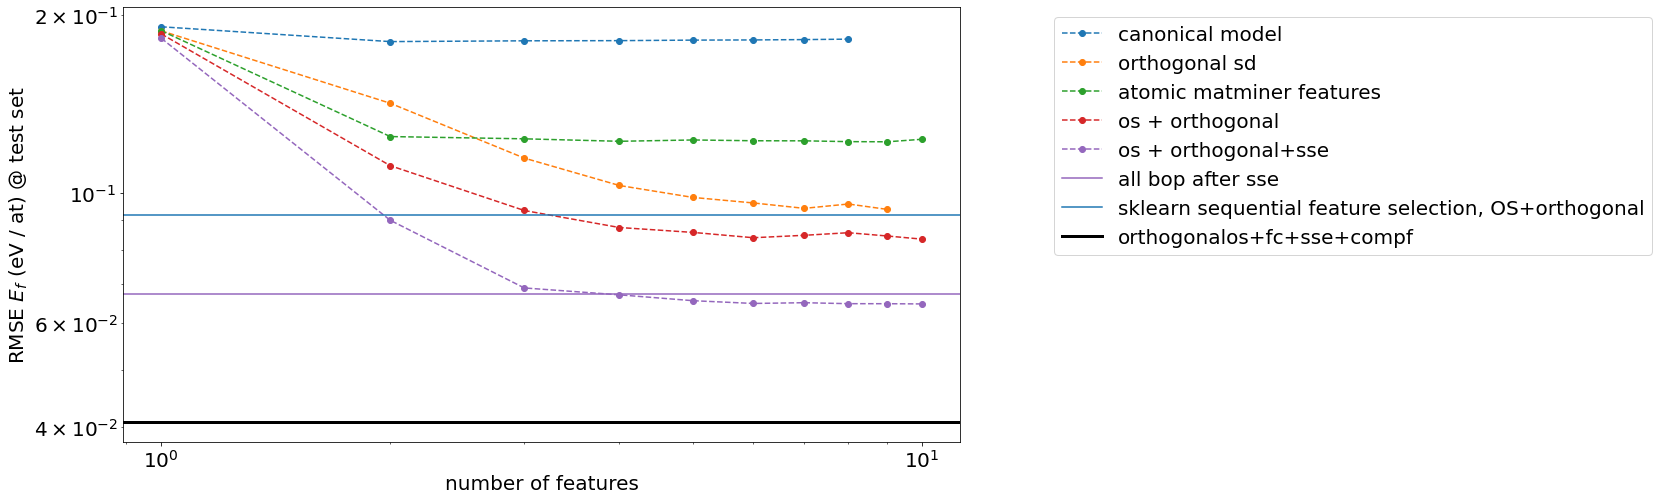

In [56]:
fig, ax = plt.subplots()
ax.plot(canonical_performance.index+1, canonical_performance['Score'],'o--', label='canonical model')
ax.plot(orthogonal_performance.index+1, orthogonal_performance['Score'],'o--', label='orthogonal sd')
ax.plot(Atomic_performance.index+1, Atomic_performance['Score'],'o--', label='atomic matminer features')
ax.plot(orthogonalos_performance.index+1, orthogonalos_performance['Score'],'o--', label='os + orthogonal')
l = ax.plot(orthogonalos_sse.index+1, orthogonalos_sse['Score'],'o--', label='os + orthogonal+sse')[0]
ax.axhline(mse_sse['After_3_FRR']['test'], label='all bop after sse', c=l.get_color())
ax.axhline(msesselectons['RF_After_SeqSelection']['test'],label = 'sklearn sequential feature selection, OS+orthogonal')
ax.axhline(mse_sse['selected_features_w_compo']['test'],label='orthogonalos+fc+sse+compf',c='k', lw = 3)
ax.ahline(mse_sse[''])
ax.set_ylabel ('RMSE $E_f$ (eV / at) @ test set')
ax.set_xlabel ('number of features')
ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(bbox_to_anchor=(1.1,1))
fig.savefig('graphs/incremental_domain_knowledge.pdf')

In [20]:
Atomic_performance['Feature']=Atomic_performance['Feature'].str.replace('MagpieData','')

In [21]:
from importlib.machinery import SourceFileLoader

In [22]:
Atomic_performance['Feature'].drop(0)

1       mean AtomicWeight
2     avg_dev GSvolume_pa
3          mode NdValence
4         mode NpUnfilled
5         mode NfUnfilled
6          mode NsValence
7         mean NfUnfilled
8          mean NpValence
9       avg_dev NpValence
Name: Feature, dtype: object

In [23]:
feature_titles_canonical

Feature
MagConfig_0          $MagConfig$
NSC_moments_6            $m_{6}$
NSC_bn_2               $b^{(2)}$
NSC_SIGMA_5       $\sigma^{(5)}$
NSC_SIGMA_3       $\sigma^{(3)}$
NSC_SIGMA_17     $\sigma^{(17)}$
NSC_U_bind_0          $U_{bind}$
NSC_SIGMA_19     $\sigma^{(19)}$
dtype: object

In [24]:
Plotting = SourceFileLoader('Plotting','Tools.py').load_module().Plotting
ax1 = Plotting.plot_learning_curve( canonical_performance['Score'][1:].values,  feature_titles_canonical.drop('MagConfig'))
ax2 = Plotting.plot_learning_curve(orthogonal_performance['Score'][1:].values, feature_titles_orthogonal.drop('MagConfig'), ax = ax1)
ax3 = Plotting.plot_learning_curve(Atomic_performance['Score'][1:].values, Atomic_performance['Feature'].drop(0), ax = ax2)
ax3 = Plotting.plot_learning_curve(orthogonalos_performance['Score'][1:].values, feature_titles_orthogonalos.drop('MagConfig'), ax = ax2)

KeyError: "['MagConfig'] not found in axis"

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso

In [ ]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
from importlib.machinery import SourceFileLoader
import re
import sys
from tqdm.notebook import tqdm_notebook
from seaborn import heatmap
import seaborn as sns
from BopFoxFeaturizer.HelperFunctions import get_useful_features
from BopFoxFeaturizer.HelperFunctions import cleanfeaturenames
from BopFoxFeaturizer.HelperFunctions import histoff_realfeatures
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)
from BopFoxFeaturizer.FeatureConcatenate import stackdata
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from BopFoxFeaturizer.Featurizer import Featurizer
from BopFoxFeaturizer import HelperFunctions as HF
#stackdata = SourceFileLoader('stackdata','BopFoxFeaturizer/FeatureConcatenate.py').load_module().stackdata
# Original DFT Data
%run SourceDevelopementVersion.py
# which loads Featu
import glob

In [ ]:
def float_and_stack(BopfoxFeatures):
    BopfoxFeatures.dropna(how='any',inplace=True)
    M = BopfoxFeatures['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
    S = BopfoxFeatures['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
    Binf=BopfoxFeatures['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
    Ainf=BopfoxFeatures['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
    AN = BopfoxFeatures['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
    BN = BopfoxFeatures['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
    Mag = Features.MagFeature[BopfoxFeatures.index]
    BOP_atom_average = pd.concat([BopfoxFeatures['NSC_U_bind'],M, S, AN, BN, Ainf, Binf, Mag], axis=1)
    # Feature Transformation to concatenation
    BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
    BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)
    return BOP

In [ ]:
BOPCANONICAL = pd.read_pickle('CRCOW_INITIAL_NSC_CANONICAL_TABLECUTOFF_WUBIND_15.pkl')

In [ ]:
BOPORTHOGONAL = pd.read_pickle('CRCOW_INITIAL_NSC_ORTHOGONAL_TABLECUTOFF_WUBIND_15.pkl')

In [ ]:
BOPORTHOGONALOS = pd.read_pickle('CRCOW_INITIAL_NSC_ORTHOGONALOS_TABLECUTOFF_WUBIND_15.pkl')

In [ ]:
models = [BOPCANONICAL, BOPORTHOGONAL, BOPORTHOGONALOS]

In [ ]:
ALLBOP = [float_and_stack(BOP) for BOP in models] 

In [ ]:
[BOP.dropna(how='any', inplace=True) for BOP in ALLBOP]

In [ ]:
BS = StructSummaryParser().BriefSummary
Features = Featurizer(BS)

In [ ]:
groundstates=Features.get_ground_states_energies()
BS['EF'] = Features.get_formation_energy(ground_states_dic=groundstates)
BS = BS.dropna()

In [ ]:
Mag = Features.MagFeature[BOPCANONICAL.index]
ALLBOP[0]['MagConfig'] = Mag

In [ ]:
Mag = Features.MagFeature[BOPORTHOGONAL.index]
ALLBOP[1]['MagConfig'] = Mag

In [ ]:
Mag = Features.MagFeature[BOPORTHOGONALOS.index]
ALLBOP[2]['MagConfig'] = Mag

In [ ]:
regressor =  RandomForestRegressor()

In [ ]:
models[-1].columns

In [ ]:
fitted_ef = []
for BOP in ALLBOP:
    DATA = BOP.copy()
    DATA[['B0','V0','EF','E0']]=BS[['B0','V0','EF','E0']]
    DATA = DATA[(DATA['EF'] > -1) & (DATA['EF']< 2)]
    DATA = DATA[(DATA['E0']>-100) & (DATA['E0']<10)]
    DATA = DATA[(DATA['B0'])>0 & (DATA['B0']<500)]
    DATA = DATA[DATA['V0']<50]
    real_feature = HF.get_useful_features(BOP, BOP.columns)
    DATA.dropna(how='any', axis=0,inplace=True)
    fitted_model = regressor.fit(DATA[real_feature], DATA['EF'])
    fitted_ef.append(regressor.predict(DATA[real_feature]))
    
    

In [ ]:
plt.plot(fitted_ef[0], DATA['EF'],'o', label = 'canonical model')
plt.plot(fitted_ef[1], DATA['EF'],'o',label = 'bond specific')
plt.plot(fitted_ef[2], DATA['EF'],'o',label = 'bond specific + OS')
plt.plot(DATA['EF'], DATA['EF'],'-k')
plt.ylabel('True $E_f$ (eV/at)')
plt.xlabel('predicted $E_f$ (eV/at)')
plt.legend()
plt.savefig('graphs/domainknowledgepredictionline.pdf')